# MIS 548 Final Project — Problem 2 (OUD Dropout)

**Goal:** Predict whether a treatment episode ends in **DROPOUT** (binary classification).

## Setup

In [ ]:
# Install xgboost if needed (Colab)
try:
    import xgboost
except ImportError:
    !pip -q install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

## Helper Functions

In [ ]:
def basic_profile(df, name="data"):
    print(f"=== {name} shape ===", df.shape)
    display(df.head())
    print("\n=== dtypes ===")
    display(df.dtypes)
    print("\n=== missing values (top 25) ===")
    miss = df.isna().sum().sort_values(ascending=False)
    display(miss.head(25))

def plot_binary_distribution(y, title):
    vc = pd.Series(y).value_counts().sort_index()
    plt.figure()
    vc.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Class (0=No, 1=Yes)")
    plt.ylabel("Count")
    plt.show()

def evaluate_binary(y_true, y_prob, threshold=0.5):
    """
    Compute multiple metrics for a comprehensive evaluation.
    ROC_AUC uses probabilities; others use a chosen threshold.
    """
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

def plot_roc_curve(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{title} (AUC={roc_auc:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()
    return roc_auc

def plot_confusion(y_true, y_prob, title, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title} — Confusion Matrix (thr={threshold})")
    plt.xticks([0,1], ["Pred 0","Pred 1"])
    plt.yticks([0,1], ["True 0","True 1"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def subgroup_auc_table(y_true, y_prob, group_series, min_size=100):
    rows = []
    gs = group_series.astype("object")
    y_true = pd.Series(y_true, index=gs.index)
    y_prob = pd.Series(y_prob, index=gs.index)
    for g, idx in gs.groupby(gs).groups.items():
        yt = y_true.loc[idx]
        yp = y_prob.loc[idx]
        if len(idx) < min_size or yt.nunique() < 2:
            continue
        rows.append({"group": g, "n": len(idx), "auc": roc_auc_score(yt, yp)})
    return pd.DataFrame(rows).sort_values("auc", ascending=False)

def build_nn(input_dim, hidden_units=(128, 64), dropout=0.3, lr=1e-3):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))
    for hu in hidden_units:
        model.add(keras.layers.Dense(hu, activation="relu"))
        model.add(keras.layers.Dropout(dropout))
    model.add(keras.layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

## 1) Load Data

=== OUD dataset shape === (95432, 28)


,ALCFLG,ARRESTS,EDUC,EMPLOY,ETHNIC,GENDER,INHFLG,LIVARAG,MARFLG,MARSTAT,...,STFIPS,FREQMAX,NEEDLEUSE,STIMFLAG,TRNQFLAG,SEDFLAG,HALFLAG,HEROIN,AGECAT,DROPOUT
0,0,0,3,3,4,2,0,3,0,1,...,24,3,1,0,0,0,0,1,2,0
1,0,0,3,3,4,2,0,3,0,2,...,36,3,1,1,0,0,0,1,2,0
2,0,0,3,3,4,2,0,2,0,2,...,49,3,1,0,0,0,0,1,3,0
3,1,0,4,4,2,2,0,2,0,1,...,2,3,1,1,0,0,0,1,2,1
4,0,0,2,4,4,2,0,3,1,2,...,4,3,1,1,0,0,0,1,1,0



=== dtypes ===


,0
ALCFLG,int64
ARRESTS,int64
EDUC,int64
EMPLOY,int64
ETHNIC,int64
GENDER,int64
INHFLG,int64
LIVARAG,int64
MARFLG,int64
MARSTAT,int64



=== missing values (top 25) ===


,0
ALCFLG,0
ARRESTS,0
EDUC,0
EMPLOY,0
ETHNIC,0
GENDER,0
INHFLG,0
LIVARAG,0
MARFLG,0
MARSTAT,0


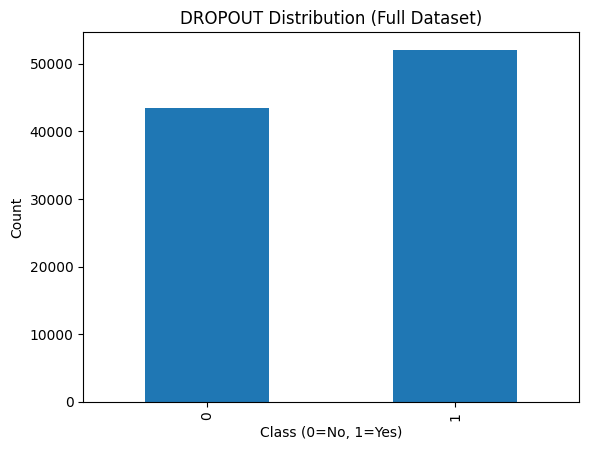

In [ ]:
oud_url = "https://guoyuanxiong.github.io/teaching/OUD/processed_data_2018.csv"
oud = pd.read_csv(oud_url)

basic_profile(oud, "OUD dataset")

target = "DROPOUT"
plot_binary_distribution(oud[target], "DROPOUT Distribution (Full Dataset)")

## 2) Train/Test Split + Preprocessing

In [ ]:
X = oud.drop(columns=[target])
y = oud[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols)
    ],
    remainder="drop"
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))

Train shape: (76345, 27) Test shape: (19087, 27)
Numeric cols: 27 Categorical cols: 0


## 3) Train Models

### 3.1 Logistic Regression

In [ ]:
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=500))
])
pipe_lr.fit(X_train, y_train)
p_lr = pipe_lr.predict_proba(X_test)[:, 1]
metrics_lr = evaluate_binary(y_test, p_lr)
metrics_lr

{'Accuracy': 0.6097867658615812,
 'Precision': 0.6131498470948012,
 'Recall': 0.7705611068408916,
 'F1': 0.6829019073569482,
 'ROC_AUC': np.float64(0.6378874482470209)}

### 3.2 XGBoost + GridSearch (Tuned)

In [ ]:
pipe_xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

gs_xgb = GridSearchCV(pipe_xgb, param_grid=param_grid_xgb, scoring="roc_auc", cv=5, n_jobs=-1, verbose=0)
gs_xgb.fit(X_train, y_train)

print("Best XGB params:", gs_xgb.best_params_)

p_xgb = gs_xgb.predict_proba(X_test)[:, 1]
metrics_xgb = evaluate_binary(y_test, p_xgb)
metrics_xgb

Best XGB params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 400, 'model__subsample': 0.8}


{'Accuracy': 0.6765337664378896,
 'Precision': 0.6716393708448192,
 'Recall': 0.7959262106072252,
 'F1': 0.7285199190924281,
 'ROC_AUC': np.float64(0.7391712130555533)}

### 3.3 Neural Network (MLP)

In [ ]:
X_train_pp = preprocess.fit_transform(X_train)
X_test_pp = preprocess.transform(X_test)

if hasattr(X_train_pp, "toarray"):
    X_train_pp = X_train_pp.toarray()
    X_test_pp = X_test_pp.toarray()

input_dim = X_train_pp.shape[1]
print("NN input_dim:", input_dim)

nn = build_nn(input_dim, hidden_units=(128, 64), dropout=0.3, lr=1e-3)
hist = nn.fit(
    X_train_pp, y_train,
    validation_split=0.2,
    epochs=20, batch_size=128,
    verbose=0
)

p_nn = nn.predict(X_test_pp, verbose=0).ravel()
metrics_nn = evaluate_binary(y_test, p_nn)
metrics_nn

NN input_dim: 27


{'Accuracy': 0.6492377010530728,
 'Precision': 0.6406332853571699,
 'Recall': 0.8125480399692544,
 'F1': 0.7164217035876149,
 'ROC_AUC': np.float64(0.7045145460089508)}

## 4) Compare Models (Table + Bar Chart)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,XGBoost,0.676534,0.671639,0.795926,0.728520,0.739171
2,Neural Network,0.649238,0.640633,0.812548,0.716422,0.704515
0,Logistic Regression,0.609787,0.613150,0.770561,0.682902,0.637887


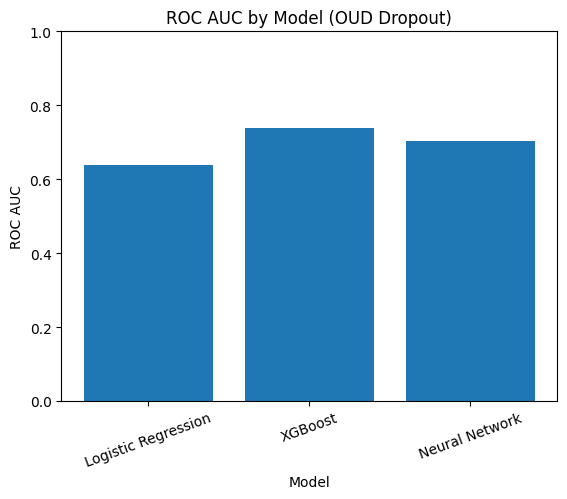

In [ ]:
comparison = pd.DataFrame([
    {"Model": "Logistic Regression", **metrics_lr},
    {"Model": "XGBoost", **metrics_xgb},
    {"Model": "Neural Network", **metrics_nn},
])
display(comparison.sort_values("ROC_AUC", ascending=False))

# Bar chart for ROC_AUC (presentation-friendly)
plt.figure()
plt.bar(comparison["Model"], comparison["ROC_AUC"])
plt.title("ROC AUC by Model (OUD Dropout)")
plt.xlabel("Model")
plt.ylabel("ROC AUC")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

## 5) ROC Curves + Confusion Matrices (Model-Supporting Visualizations)

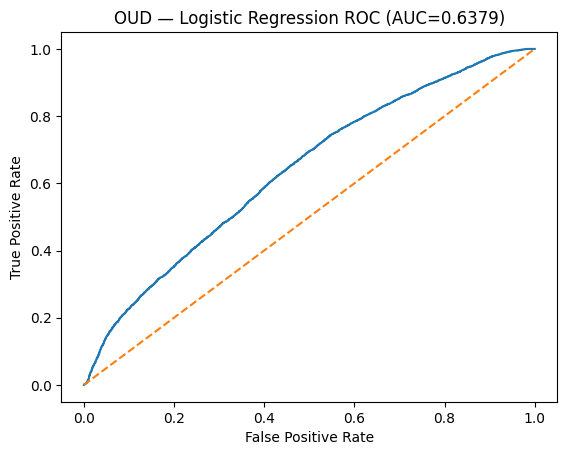

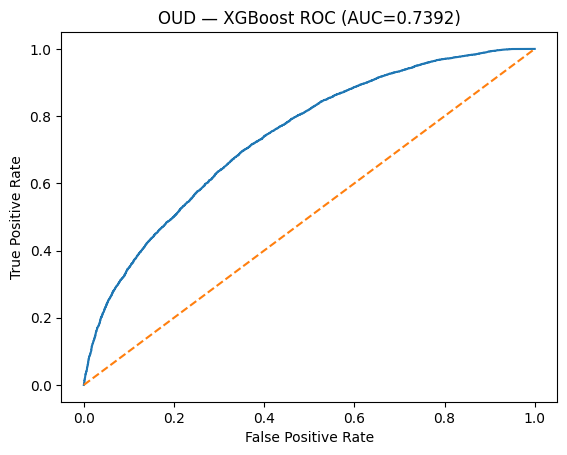

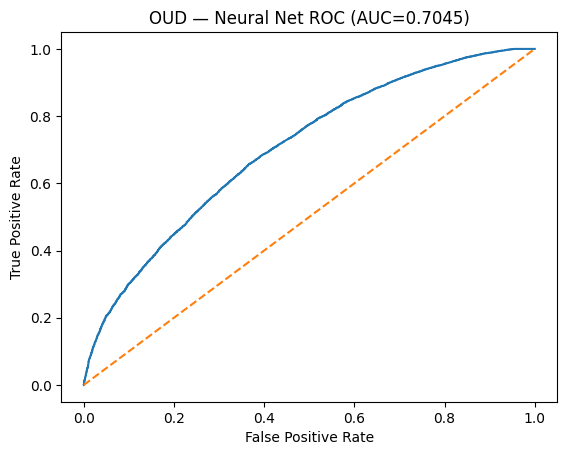

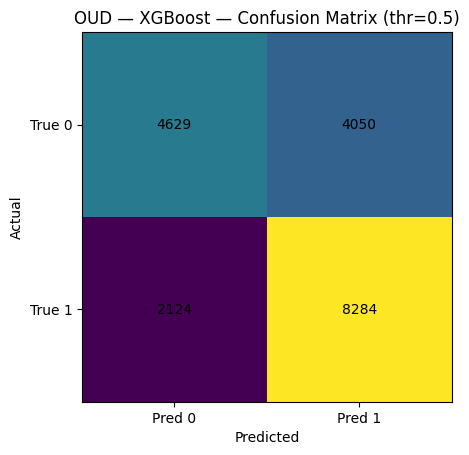

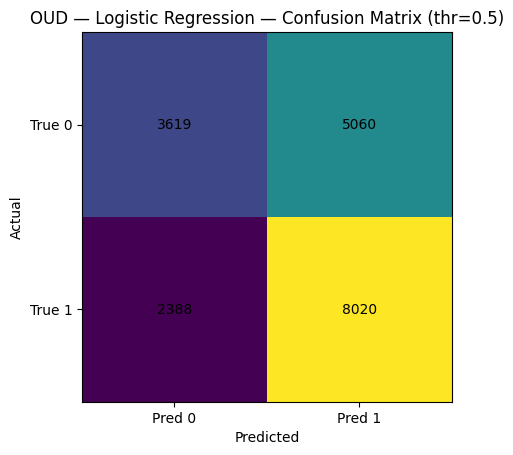

In [ ]:
# ROC curves make model comparison visual (not just numbers).
plot_roc_curve(y_test, p_lr, "OUD — Logistic Regression ROC")
plot_roc_curve(y_test, p_xgb, "OUD — XGBoost ROC")
plot_roc_curve(y_test, p_nn, "OUD — Neural Net ROC")

# Confusion matrices at threshold=0.5 (interpretability)
plot_confusion(y_test, p_xgb, "OUD — XGBoost", threshold=0.5)
plot_confusion(y_test, p_lr, "OUD — Logistic Regression", threshold=0.5)

## 6) Feature Importance (XGBoost)

Could not extract one-hot feature names automatically. Proceeding without names.


,feature,importance
18,f18,0.132566
16,f16,0.123678
19,f19,0.114972
12,f12,0.062792
15,f15,0.061048
2,f2,0.055225
13,f13,0.029518
14,f14,0.029114
17,f17,0.028474
7,f7,0.028400


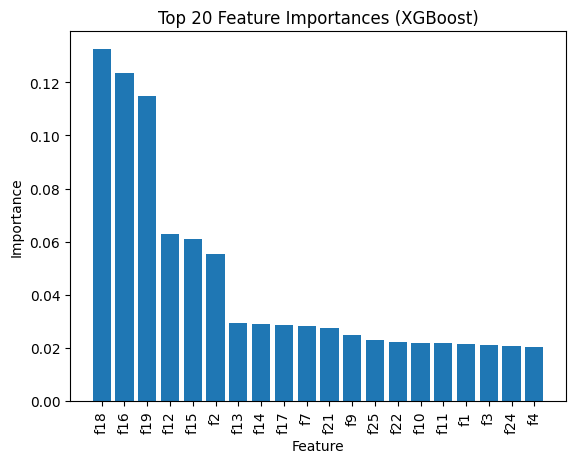

In [ ]:
# XGBoost has built-in feature importances.
# After preprocessing (one-hot), features expand; we reconstruct feature names.

_ = preprocess.fit(X_train)

feature_names = []
try:
    num_features = num_cols
    cat_feature_names = preprocess.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols).tolist()
    feature_names = num_features + cat_feature_names
except Exception as e:
    print("Could not extract one-hot feature names automatically. Proceeding without names.")
    feature_names = None

xgb_model = gs_xgb.best_estimator_.named_steps["model"]
importances = xgb_model.feature_importances_

if feature_names is None or len(feature_names) != len(importances):
    imp_df = pd.DataFrame({"feature": [f"f{i}" for i in range(len(importances))], "importance": importances})
else:
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})

imp_df = imp_df.sort_values("importance", ascending=False).head(20)
display(imp_df)

plt.figure()
plt.bar(imp_df["feature"], imp_df["importance"])
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()

## 7) Subgroup Analysis (AGECA, RACE, GENDER, STFIPS)

In [ ]:
# Required subgroup evaluation.
# We use XGBoost probabilities by default (often strongest performer).

best_prob = pd.Series(p_xgb, index=X_test.index)

for group_col in ["AGECA", "RACE", "GENDER", "STFIPS"]:
    if group_col in X_test.columns:
        print(f"\n=== Subgroup ROC AUC by {group_col} (XGBoost) ===")
        display(subgroup_auc_table(y_test, best_prob, X_test[group_col], min_size=100))


=== Subgroup ROC AUC by RACE (XGBoost) ===


,group,n,auc
0,-9,338,0.898675
1,2,292,0.779497
5,8,384,0.778315
3,5,13446,0.732344
4,7,1988,0.715035
2,4,2464,0.713349



=== Subgroup ROC AUC by GENDER (XGBoost) ===


,group,n,auc
0,1,11310,0.739721
1,2,7774,0.738075



=== Subgroup ROC AUC by STFIPS (XGBoost) ===


,group,n,auc
1,4,745,0.863160
18,37,192,0.776046
7,17,155,0.763833
5,10,131,0.756604
2,6,2370,0.737945
20,42,312,0.725720
6,12,331,0.706312
14,27,564,0.702902
15,29,167,0.701866
11,24,856,0.662633
